In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

aerial_cactus_identification_path = kagglehub.competition_download('aerial-cactus-identification')

print('Data source import complete.')


# 데이터 둘러보기

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
data_path = '/kaggle/input/aerial-cactus-identification/'

In [ ]:
labels = pd.read_csv(data_path + 'train.csv')
submission = pd.read_csv(data_path + 'sample_submission.csv')

In [ ]:
labels.head()

,id,has_cactus
0,0004be2cfeaba1c0361d39e2b000257b.jpg,1
1,000c8a36845c0208e833c79c1bffedd1.jpg,1
2,000d1e9a533f62e55c289303b072733d.jpg,1
3,0011485b40695e9138e92d0b3fb55128.jpg,1
4,0014d7a11e90b62848904c1418fc8cf2.jpg,1


In [ ]:
submission.head()

,id,has_cactus
0,000940378805c44108d287872b2f04ce.jpg,0.5
1,0017242f54ececa4512b4d7937d1e21e.jpg,0.5
2,001ee6d8564003107853118ab87df407.jpg,0.5
3,002e175c3c1e060769475f52182583d0.jpg,0.5
4,0036e44a7e8f7218e9bc7bf8137e4943.jpg,0.5


# 데이터 시각화

## 타깃값 분포

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
mpl.rc('font', size=15)
plt.figure(figsize=(7,7))

<Figure size 700x700 with 0 Axes>

<Figure size 700x700 with 0 Axes>

In [ ]:
label = ['Has cactus', 'Hasn\'t cactus'] # 타깃값 레이블

([<matplotlib.patches.Wedge at 0x7b945a93bb90>,
 [Text(-0.7793519565739234, 0.7762799287527649, 'Has cactus'),
  Text(0.7793519929142085, -0.776279892268666, "Hasn't cactus")],
 [Text(-0.42510106722213997, 0.42342541568332626, '75.1%'),
  Text(0.4251010870441137, -0.42342539578290866, '24.9%')])

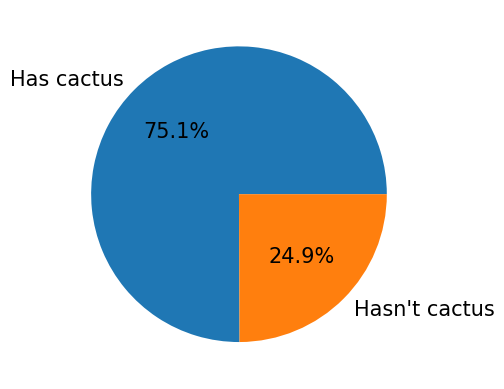

In [ ]:
# 타깃값 분포 파이 그래프
plt.pie(labels['has_cactus'].value_counts(), labels=label, autopct='%.1f%%')

## 이미지 출력

In [ ]:
from zipfile import ZipFile

In [ ]:
# 훈련 이미지 데이터 압축 풀기
with ZipFile(data_path + 'train.zip') as zipper:
    zipper.extractall()

In [ ]:
# 테스트 이미지 데이터 압축 풀기
with ZipFile(data_path + 'test.zip') as zipper:
    zipper.extractall()

In [ ]:
import os

In [ ]:
num_train = len(os.listdir('train/'))
num_test = len(os.listdir('test/'))

In [ ]:
print(f'훈련 데이터 개수: {num_train}')
print(f'테스트 데이터 개수: {num_test}')

훈련 데이터 개수: 17500
테스트 데이터 개수: 4000


In [ ]:
import matplotlib.gridspec as gridspec
import cv2

In [ ]:
mpl.rc('font', size=7)
plt.figure(figsize=(15,6))
grid = gridspec.GridSpec(2, 6)

<Figure size 1500x600 with 0 Axes>

In [ ]:
# 선인장을 포함하는 이미지 파일명(마지막 12개)
last_has_cactus_img_name = labels[labels['has_cactus']==1]['id'][-12:]

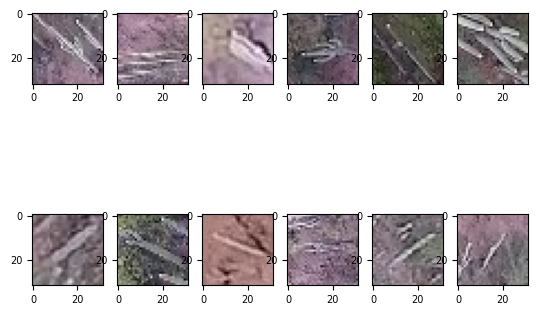

In [ ]:
# 이미지 출력
for idx, img_name in enumerate(last_has_cactus_img_name):
    img_path = 'train/' + img_name
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    ax = plt.subplot(grid[idx])
    ax.imshow(image)

In [ ]:
plt.figure(figsize=(15,6))
grid = gridspec.GridSpec(2, 6)

<Figure size 1500x600 with 0 Axes>

In [ ]:
# 선인장을 포함하지 않는 이미지 파일명(마지막 12개)
last_hasnt_cactus_img_name = labels[labels['has_cactus']==0]['id'][-12:]

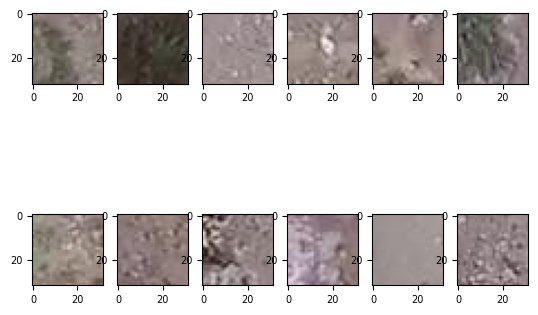

In [ ]:
# 이미지 출력
for idx, img_name in enumerate(last_hasnt_cactus_img_name):
    img_path = 'train/' + img_name
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    ax = plt.subplot(grid[idx])
    ax.imshow(image)

In [ ]:
image.shape

(32, 32, 3)